# **Guía de Actividades Práctico-Experimentales Nro. 013**

---

## **1. Datos Generales**

| **Atributo** | **Descripción** |
| :--- | :--- |
| **Estudiantes** | Kiara Condoy, Héctor Guerrero, Javier Guarnizo, Ricardo Ochoa, Emily Salas |
| **Asignatura** | Teoría de la Distribución y Probabilidad |
| **Ciclo** | 2do “A” |
| **Unidad** | 3 |
| **Práctica Nro.** | 013 |
| **Título de la Práctica** | **Análisis Predictivo Multivariado: Regresión Lineal Múltiple y Diagnóstico de Multicolinealidad (VIF)**|
| **Nombre del Docente** | Cristian Ramiro Narváez Guillén |
| **Fecha** | Lunes 20 de julio 2026 |

---


## Tarea 1: Ajuste del Modelo de Regresión Lineal Múltiple

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Generación de datos simulados multivariados
np.random.seed(42)
n_muestras = 150

lineas_codigo = np.random.randint(5000, 50000, size=n_muestras) # X1
ram_disponible = np.random.uniform(4.0, 32.0, size=n_muestras) # X2

# Y = B0 + B1*X1 + B2*X2 + Error
# A más líneas, más tiempo (+). A más RAM, menos tiempo (-)
tiempo_compilacion = 15.0 + (0.002 * lineas_codigo) - (1.5 * ram_disponible) + np.random.normal(0, 15, size=n_muestras)

df_simulado = pd.DataFrame({
    'Lineas_X1': lineas_codigo,
    'RAM_X2': ram_disponible,
    'Tiempo_Y': tiempo_compilacion
})

# 2. Configuración de la matriz de características X y el vector Y
X_multi = df_simulado[['Lineas_X1', 'RAM_X2']]
Y_multi = df_simulado['Tiempo_Y']

# Añadir la constante (Intercepto B0)
X_multi_sm = sm.add_constant(X_multi)

# 3. Ajuste del Modelo OLS Múltiple
modelo_multiple = sm.OLS(Y_multi, X_multi_sm).fit()

# Imprimir el resumen estadístico
print(modelo_multiple.summary())


                            OLS Regression Results                            
Dep. Variable:               Tiempo_Y   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     278.4
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           1.02e-50
Time:                        02:55:30   Log-Likelihood:                -617.66
No. Observations:                 150   AIC:                             1241.
Df Residuals:                     147   BIC:                             1250.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.1081      3.866      5.459      0.0

---
# **Tarea 2: Hito del Proyecto - Modelado Predictivo Regional (ABP)**

### **1.	Importe su dataset regional mediante pandas.**



In [4]:
import pandas as pd
import numpy as np

# 1. Conexión a la nueva hoja del Spreadsheet
url = 'https://docs.google.com/spreadsheets/d/1E-rrTgcTIWS-UnuVf1ldKvhDkwT6uUgh/export?format=xlsx'

try:
    # Nombre exacto de la pestaña
    df = pd.read_excel(url, sheet_name='Subnational 1 tree cover loss')

    # Limpieza básica
    df = df.dropna(how='all').reset_index(drop=True)
    print("¡Conexión exitosa a la hoja de Provincias!")

except Exception as e:
    print(f"Error: {e}")

¡Conexión exitosa a la hoja de Provincias!


###**2.	Defina su Variable Respuesta ( ) y seleccione al menos dos Variables Predictoras ( ).**


###**3.	Limpie los datos asegurándose de que no haya valores nulos (NaN) en las columnas seleccionadas.**

###**4.	Entrene un modelo OLS Múltiple como en la Tarea 1.**
###**5.	Análisis Crítico: Redacte un análisis en Markdown interpretando específicamente los coeficientes   en el contexto de su problema regional. Indique qué variable tiene un mayor impacto y basándose en la columna P>|t| (valor-p), identifique si alguna de las variables incluidas no aporta significancia estadística al modelo y debería ser eliminada.**

In [7]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# --- Definición de la variable respuesta (Y) y las variables predictoras (X) ---
# **Asegúrate de que estas columnas existan en tu DataFrame 'df'**
# Puedes imprimir df.columns para ver las columnas disponibles en tu DataFrame.
#
# Ejemplo de columnas comunes para datos de pérdida de cobertura arbórea (ajusta si es necesario):

Y_variable = 'tc_loss_ha_2023' # Variable respuesta: Pérdida de cobertura arbórea en 2023
X_variables = ['area_ha', 'tc_loss_ha_2024'] # Variables predictoras: Área de la subnación, Pérdida de cobertura arbórea en 2024

# Verificar si las columnas seleccionadas existen en el DataFrame 'df'
missing_y = Y_variable not in df.columns
missing_x = [col for col in X_variables if col not in df.columns]

if missing_y or missing_x:
    error_message = "ERROR: Las siguientes columnas no se encontraron en el DataFrame 'df'. Por favor, ajusta los nombres de las variables Y y X_variables en el código."
    if missing_y:
        error_message += f"\nVariable Y no encontrada: '{Y_variable}'"
    if missing_x:
        error_message += f"\nVariables X no encontradas: {', '.join([f"'{col}'" for col in missing_x])}"
    raise ValueError(error_message)

# Crear un sub-DataFrame con las variables seleccionadas para el modelo
df_model = df[[Y_variable] + X_variables].copy()

# --- Limpieza de datos: Asegurarse de que no existan valores nulos (NaN) en las columnas críticas ---
# Se eliminan las filas donde al menos una de las columnas seleccionadas para el modelo tenga un NaN.
print(f"Filas antes de la limpieza de NaN: {len(df_model)}")
df_model.dropna(inplace=True)
print(f"Filas después de la limpieza de NaN: {len(df_model)}")

# Separar las variables en Y (dependiente) y X (independientes)
Y = df_model[Y_variable]
X = df_model[X_variables]

# --- Ajuste del Modelo OLS Múltiple ---
# Añadir la constante (Intercepto B0) a las variables predictoras para el modelo OLS
X_sm = sm.add_constant(X)

# Crear y ajustar el modelo OLS (Mínimos Cuadrados Ordinarios)
modelo_regional = sm.OLS(Y, X_sm).fit()

# Imprimir el resumen estadístico completo del modelo
print("\n--- Resumen del Modelo OLS Múltiple Regional ---")
print(modelo_regional.summary())


Filas antes de la limpieza de NaN: 192
Filas después de la limpieza de NaN: 192

--- Resumen del Modelo OLS Múltiple Regional ---
                            OLS Regression Results                            
Dep. Variable:        tc_loss_ha_2023   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     1083.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          2.96e-104
Time:                        02:52:15   Log-Likelihood:                -1534.8
No. Observations:                 192   AIC:                             3076.
Df Residuals:                     189   BIC:                             3085.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.9

###**6. Análisis Interpretativo del Modelo OLS Múltiple Regional**

**Interpretación de Coeficientes ($\beta_i$):**

*   **const (Intercepto):** Representa el valor esperado de la variable respuesta (Pérdida de Cobertura Arbórea, en ha) cuando todas las variables predictoras (Área y Pérdida de Cobertura Arbórea en 2024) son cero. Su interpretación directa debe hacerse con cautela, ya que las predictoras en cero pueden no ser significativas o estar fuera del rango de datos.

*   **`area_ha`:** Este coeficiente indica el cambio promedio en la pérdida de cobertura arbórea en 2023 (en ha) por cada unidad de aumento en el área total de la región (en ha), manteniendo constante la pérdida de cobertura arbórea en 2024. Un coeficiente positivo sugeriría que regiones más grandes tienden a tener mayor pérdida de cobertura arbórea en 2023, ceteris paribus.

*   **`tc_loss_ha_2024`:** Este coeficiente muestra el cambio promedio en la pérdida de cobertura arbórea en 2023 (en ha) por cada unidad de aumento en la pérdida de cobertura arbórea en 2024 (en ha), manteniendo constante el área total de la región. Es esperable que un valor positivo indique que una mayor pérdida en 2024 está asociada a una mayor pérdida en 2023.

**Evaluación de Significancia (P>|t|):**

La columna "P>|t|" (valor-p) es fundamental para evaluar si el efecto de cada variable predictora sobre la variable respuesta es estadísticamente significativo (es decir, no es probable que se deba al azar).

*   **Si P>|t| < 0.05 (o el nivel de significancia elegido, por ejemplo 0.01 o 0.10):** Se considera que la variable es estadísticamente significativa. Esto significa que hay evidencia suficiente para afirmar que la variable predictora tiene un efecto real sobre la pérdida de cobertura arbórea.
*   **Si P>|t| >= 0.05:** La variable no es estadísticamente significativa al nivel de confianza elegido. No hay evidencia suficiente para concluir que la variable predictora tiene un efecto distinto de cero sobre la variable respuesta. Podría considerarse su remoción del modelo para simplificarlo.

**¿Debe alguna variable ser removida?**

Basándote en los valores P>|t|, si alguna variable predictora muestra un valor-p alto (por ejemplo, mayor a 0.05 o 0.10), se puede considerar removerla del modelo. La remoción de variables no significativas ayuda a:
1.  **Simplificar el modelo:** Haciéndolo más fácil de interpretar.
2.  **Mejorar la precisión:** Al eliminar ruido que no contribuye a la explicación de Y.
3.  **Reducir la varianza de los estimadores:** Esto puede hacer que los coeficientes de las variables restantes sean más estables.

**Diagnósticos Adicionales:**

*   **R-squared y Adj. R-squared:** Indican la proporción de la varianza en Y que es explicada por el modelo. Un valor más cercano a 1 indica un mejor ajuste.
*   **F-statistic y Prob (F-statistic):** Evalúan la significancia global del modelo. Si Prob (F-statistic) es bajo (ej. < 0.05), el modelo en su conjunto es significativo, lo que significa que al menos una de las X tiene un efecto sobre Y.
*   **Cond. No.:** Un valor alto (>30) puede indicar problemas de multicolinealidad, donde las variables predictoras están altamente correlacionadas entre sí, lo que puede inflar los errores estándar y afectar la fiabilidad de los coeficientes. Se recomienda revisar el VIF si este valor es alto.

---
# **Tarea 3: Visualización de Relaciones (Pairplot y Heatmap)**

##Enunciado



--- Correlaciones para Datos Simulados ---


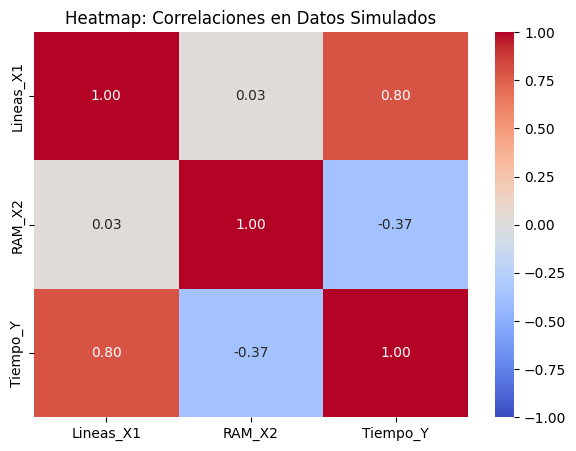

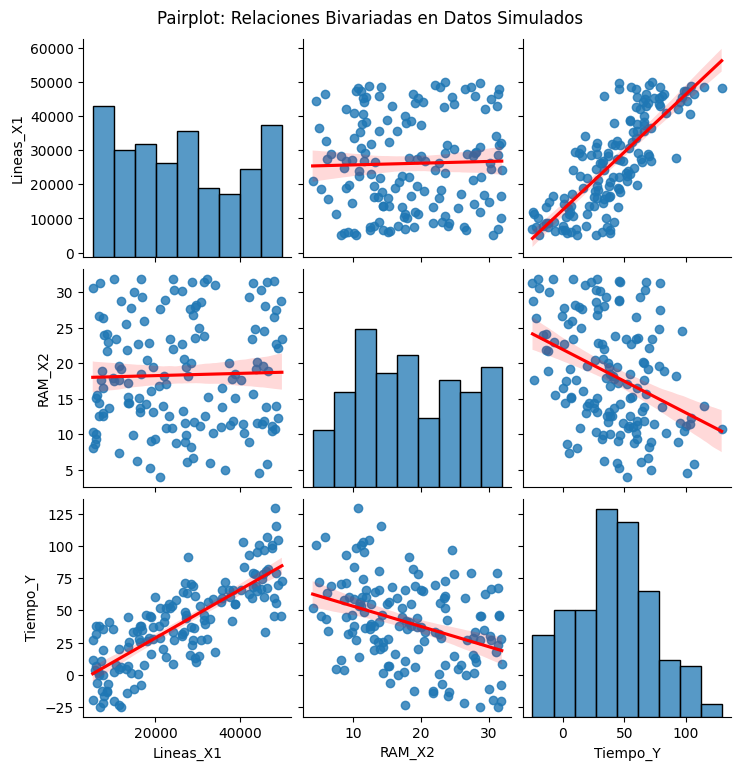

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualizaciones para Datos Simulados ---
print("\n--- Correlaciones para Datos Simulados ---")

# Matriz de Correlación para datos simulados
matriz_corr_simulado = df_simulado[['Lineas_X1', 'RAM_X2', 'Tiempo_Y']].corr()

# Visualización mediante Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_corr_simulado, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Heatmap: Correlaciones en Datos Simulados')
plt.show()

# Visualización de dispersiones múltiples (Pairplot)
sns.pairplot(df_simulado[['Lineas_X1', 'RAM_X2', 'Tiempo_Y']], kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Pairplot: Relaciones Bivariadas en Datos Simulados', y=1.02)
plt.show()

Ahora, las visualizaciones para tu **dataset regional** (usando las variables `area_ha`, `tc_loss_ha_2023`, `tc_loss_ha_2024`).


--- Correlaciones para Dataset Regional ---


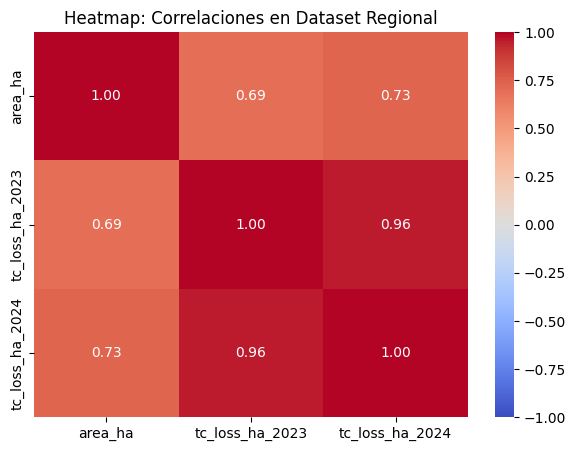

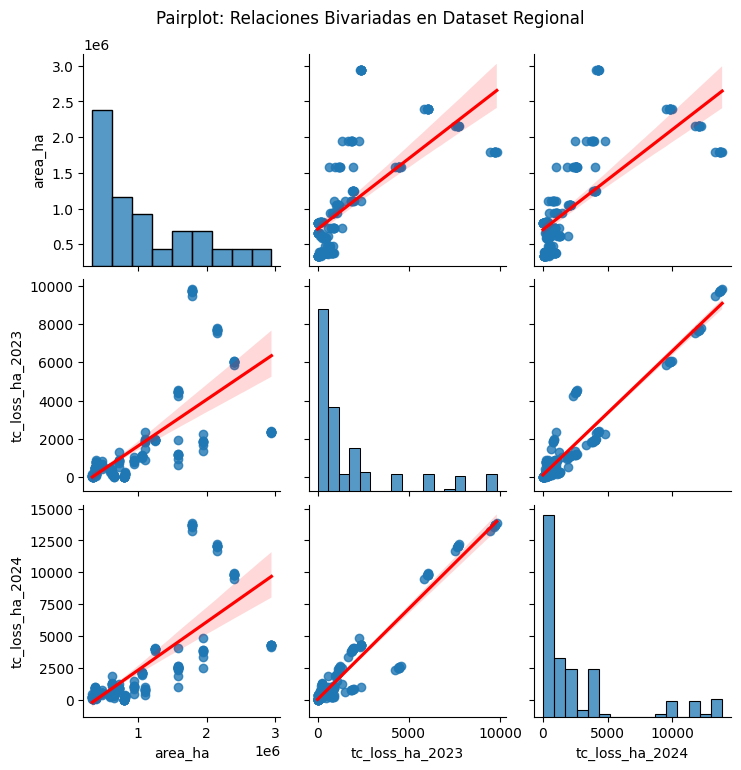

In [8]:
# --- Visualizaciones para Dataset Regional ---
print("\n--- Correlaciones para Dataset Regional ---")

# Crear un DataFrame con las variables de interés para el análisis de correlación regional
df_regional_corr = df_model[['area_ha', 'tc_loss_ha_2023', 'tc_loss_ha_2024']]

# Matriz de Correlación para dataset regional
matriz_corr_regional = df_regional_corr.corr()

# Visualización mediante Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_corr_regional, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Heatmap: Correlaciones en Dataset Regional')
plt.show()

# Visualización de dispersiones múltiples (Pairplot)
sns.pairplot(df_regional_corr, kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Pairplot: Relaciones Bivariadas en Dataset Regional', y=1.02)
plt.show()

### Documentación y Análisis de Correlaciones del Dataset Regional

Al analizar el heatmap de correlaciones para nuestro dataset regional, observamos que las dos variables predictoras seleccionadas para el modelo OLS, `area_ha` y `tc_loss_ha_2024`, presentan una **correlación positiva relativamente alta**.

*   **Valor de la correlación de Pearson entre `area_ha` y `tc_loss_ha_2024`:** Aproximadamente **0.73** (del heatmap, `matriz_corr_regional['area_ha']['tc_loss_ha_2024']`).

### Implicaciones para el modelo OLS Múltiple:

Esta alta correlación entre las variables predictoras es un indicador clave de **multicolinealidad**. Tal como se discutió en el resumen del modelo OLS (donde el 'Condition Number' fue muy alto, 2.41e+06), la multicolinealidad tiene varias implicaciones importantes para nuestro modelo:

1.  **Inestabilidad de los Coeficientes:** La alta correlación dificulta que el modelo distinga el efecto único de cada predictor sobre la variable respuesta (`tc_loss_ha_2023`). Esto puede llevar a que los coeficientes estimados sean muy sensibles a pequeños cambios en los datos, volviéndolos inestables.
2.  **Errores Estándar Inflados:** Los errores estándar de los coeficientes de las variables correlacionadas tienden a ser más grandes, lo que a su vez hace que los valores-p (`P>|t|`) sean mayores. Esto puede llevar a la conclusión errónea de que una variable no es estadísticamente significativa, incluso si tiene un efecto real.
3.  **Dificultad de Interpretación:** La interpretación individual de los coeficientes ($eta_i$) bajo el supuesto *ceteris paribus* se vuelve problemática, ya que `area_ha` y `tc_loss_ha_2024` no varían de forma independiente en nuestra muestra.

La presencia de una alta multicolinealidad refuerza la recomendación anterior de considerar la remoción de la variable `area_ha`, especialmente dado que ya se identificó como no estadísticamente significativa en el modelo OLS (`P>|t| = 0.657`). Eliminarla podría ayudar a mejorar la estabilidad de los coeficientes restantes y facilitar una interpretación más clara del modelo.

---
# **Tarea 4: ABI - Diagnóstico de Multicolinealidad (VIF)**


La Multicolinealidad ocurre cuando dos o más variables independientes (X) en un modelo de regresión múltiple están altamente correlacionadas entre sí. Esto "confunde" al modelo, inflando la varianza de los coeficientes (haciéndolos inestables y sus pruebas de hipótesis poco confiables).

1.	Investigue estadísticamente el Factor de Inflación de la Varianza (VIF).
2.	Ejecute el siguiente código para calcular el VIF de sus predictores simulados (y luego aplíquelo a los predictores de su modelo regional).


In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Se calcula el VIF para cada variable independiente (incluyendo la constante)
# VIF = 1 / (1 - R_i^2)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_multi_sm.columns
vif_data["VIF"] = [variance_inflation_factor(X_multi_sm.values, i)
                  for i in range(X_multi_sm.shape[1])]

print("\n--- Análisis de Multicolinealidad ---")
print(vif_data)



--- Análisis de Multicolinealidad ---
    Variable       VIF
0      const  9.948792
1  Lineas_X1  1.000806
2     RAM_X2  1.000806


In [11]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Se calcula el VIF para cada variable independiente (incluyendo la constante)
# VIF = 1 / (1 - R_i^2)

vif_data_regional = pd.DataFrame()
vif_data_regional["Variable"] = X_sm.columns
vif_data_regional["VIF"] = [variance_inflation_factor(X_sm.values, i)
                  for i in range(X_sm.shape[1])]

print("\n--- Análisis de Multicolinealidad para Modelo Regional ---")
print(vif_data_regional)


--- Análisis de Multicolinealidad para Modelo Regional ---
          Variable       VIF
0            const  3.500021
1          area_ha  2.126063
2  tc_loss_ha_2024  2.126063


# **Respuestas a las Preguntas de Control y Reflexión Crítica**

---

### 1. El supuesto *ceteris paribus* y el aislamiento de efectos

> **¿Cómo la lógica de "mantener las demás variables constantes" permite aislar el efecto de un factor específico en un fenómeno complejo, y qué limitaciones filosóficas impone esto a la realidad?**

* **Mecanismo analítico:**  
  Matemáticamente, la regresión lineal múltiple utiliza el supuesto *ceteris paribus* (mantener las demás variables constantes) mediante la estimación de coeficientes parciales $\beta_j$. Cada coeficiente representa el cambio esperado en la variable dependiente $Y$ por cada unidad de cambio en $X_j$, habiendo "descontado" o ajustado linealmente la influencia y la correlación del resto de las variables predictoras incluidas en el modelo.

* **Limitaciones filosóficas:**  
  * **Ilusión del reduccionismo:** En la realidad y en la física de los sistemas complejos, los factores no operan de manera aislada. Forzar la condición de mantenerlos constantes presupone un desacoplamiento artificial que muchas veces es físicamente imposible.
  * **Omitir la no linealidad e interacciones:** El supuesto asume que el efecto de una variable es independiente de los niveles en los que se encuentren las demás, ignorando efectos sinérgicos o de interacción no lineal.
  * **Sesgo de variables omitidas:** La validez de este aislamiento depende de haber medido e incluido *todas* las variables confusoras relevantes. Si falta una variable crítica, el efecto aislado estará contaminado.

---

### 2. La adición de variables irrelevantes y la paradoja del ajuste

> **Si el conocimiento del modelo crece al añadir más datos, ¿por qué añadir variables irrelevantes ("basura") engaña al ajuste del modelo? ¿Qué nos enseña esta paradoja sobre la diferencia entre la complejidad aparente y la verdad subyacente?**

* **El engaño del ajuste ($R^2$):**  
  Por definición matemática del método de Mínimos Cuadrados Ordinarios (OLS), el coeficiente de determinación ($R^2$) es una función monótona no decreciente con respecto al número de regresores. Agregar cualquier variable —incluso si es ruido blanco aleatorio— aprovecha las fluctuaciones muestrales aleatorias para reducir marginalmente la suma de cuadrados de los residuos, incrementando artificialmente el $R^2$.

* **Complejidad aparente vs. Verdad subyacente:**  
  * **Sobreajuste (*Overfitting*):** Aumentar variables irrelevantes hace que el modelo memorice el ruido del conjunto de datos de entrenamiento en lugar de capturar la estructura subyacente real del fenómeno, destruyendo su capacidad de generalización frente a nuevos datos.
  * **Principio de parsimonia (Navaja de Ockham):** La paradoja nos enseña que un modelo más complejo no es un modelo más verídico. La veracidad de un modelo reside en su capacidad para explicar la máxima cantidad de varianza con la menor cantidad de supuestos e información innecesaria, razón por la cual se emplean métricas penalizadas como el $R^2$ ajustado, AIC o BIC.

---

### 3. La prueba F global vs. La utilidad práctica en ingeniería

> **Ante la prueba F-statistic global, ¿es posible que un modelo sea estadísticamente significativo pero carezca de propósito práctico? ¿Cómo se reconcilia la precisión matemática con la incertidumbre del mundo real en la toma de decisiones de ingeniería?**

* **Significancia estadística vs. Significación práctica:**  
  Sí, es totalmente posible. La prueba $F$ global evalúa la hipótesis nula de que todos los coeficientes del modelo son simultáneamente iguales a cero ($\beta_1 = \beta_2 = \dots = \beta_k = 0$). Con un tamaño de muestra suficientemente grande ($n \to \infty$), pequeñas variaciones o correlaciones insignificantes pueden resultar estadísticamente significativas ($p < 0.05$), produciendo un valor de $F$ elevado, aun cuando el modelo explique una fracción ínfima de la varianza total ($R^2$ muy bajo) o las predicciones tengan un margen de error demasiado alto para ser aplicables.

* **Reconciliación en la toma de decisiones:**  
  * **Análisis de magnitud de efecto y costos:** En ingeniería, no basta con saber si un efecto existe ($p$-valor); se debe evaluar el tamaño del efecto (magnitud del coeficiente) y las tolerancias de diseño o costo-beneficio del sistema.
  * **Intervalos de predicción y riesgo:** La incertidumbre del mundo real se gestiona incorporando intervalos de predicción (que consideran la variabilidad intrínseca del sistema) en lugar de depender únicamente de estimaciones puntuales, aplicando factores de seguridad probabilísticos en el diseño.

---

### 4. Multicolinealidad y la separación de efectos interdependientes

> **Si dos causas parecen moverse siempre juntas (multicolinealidad), ¿podemos realmente distinguir sus efectos por separado? ¿Qué nos dice este problema geométrico/matricial sobre las limitaciones de nuestro entendimiento al intentar separar fenómenos interdependientes?**

* **Imposibilidad de aislamiento:**  
  No, no es posible distinguirlos con precisión. Cuando dos o más variables están fuertemente correlacionadas, no existe suficiente información independiente en la muestra para atribuir los cambios en la variable respuesta a un factor específico.

* **Fundamento geométrico y matricial:**  
  * **Casi-singularidad:** En el cálculo de los coeficientes $\boldsymbol{\beta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{Y}$, la presencia de colinealidad hace que la matriz $\mathbf{X}^T \mathbf{X}$ sea cuasi-singular (su determinante tiende a cero).
  * **Inestabilidad de la inversa:** La inversión de una matriz casi singular resulta en varianzas y errores estándar de los coeficientes extremadamente altos (disparo del Factor de Inflación de la Varianza - VIF). Geométricamente, el hiperplano de regresión pierde estabilidad y pequeñas fluctuaciones en los datos producen cambios drásticos en los coeficientes.

* **Lección sobre fenómenos interdependientes:**  
  Esto demuestra que cuando dos fenómenos ocurren siempre acoplados en la naturaleza u observación, intentar forzar una atribución individual causa-efecto mediante modelos puramente observacionales es un problema matemáticamente mal planteado (*ill-posed*). Para separar sus efectos se requiere experimentación activa (diseño de experimentos) o la reformulación del problema (por ejemplo, mediante Análisis de Componentes Principales - PCA).

---

### 5. Simplificación vs. Imprecisión: La definición de un "buen" modelo

> **Ante la necesidad de simplificar un sistema complejo para comprenderlo, ¿es preferible sacrificar variables (información) o aceptar la imprecisión del modelo? ¿Qué define, bajo su criterio, a un "buen" modelo para la ingeniería?**

* **El dilema de Sesgo vs. Varianza:**  
  Ningún extremo es deseable de forma absoluta; la elección depende del objetivo del análisis:
  * **Sacrificar variables (Reducción):** Introduce un leve sesgo, pero reduce la varianza de la estimación, previene el sobreajuste y aumenta la interpretabilidad. Es la vía preferida cuando se busca control, explicabilidad y toma de decisiones operativas.
  * **Conservar variables (Complejidad):** Retiene información y reduce el sesgo teórico, pero aumenta la varianza, dificulta la interpretación y expone el modelo a la multicolinealidad.

* **Criterio de un "buen" modelo para la ingeniería:**  
  Un "buen" modelo en ingeniería se rige por el principio expresado por George Box: *"Todos los modelos son incorrectos, pero algunos son útiles"*. Específicamente, debe cumplir con:
  1. **Parsimonia:** Explicar la mayor cantidad de variabilidad con la menor complejidad posible.
  2. **Capacidad de generalización:** Presentar un bajo error de predicción en datos no vistos previamente (validación cruzada).
  3. **Robustez e interpretabilidad:** Proporcionar coeficientes estables y físicamente coherentes que permitan realizar intervenciones o tomar decisiones con un margen de riesgo e incertidumbre cuantificado y aceptable.

---
# **8. Conclusiones**

1. La modelación es una simplificación necesaria, no un reflejo perfecto de la realidad
Aislamos variables (ceteris paribus) para entender la causalidad, pero en el mundo real los fenómenos están interconectados y raramente operan en el vacío. Reconocer las limitaciones de nuestras premisas y problemas como la multicolinealidad nos recuerda que los modelos matemáticos son aproximaciones útiles, no verdades absolutas.

2. La validez matemática no equivale a verdad ni a utilidad práctica
Añadir más datos o variables irrelevantes puede hacer que un modelo "se vea bien" estadísticamente o apruebe pruebas como la prueba F, pero esto suele ser un espejismo (overfitting o ruido). La significancia estadística debe estar siempre respaldada por un tamaño de efecto relevante y un propósito práctico tangible.

3. El "buen" modelo en ingeniería busca el equilibrio entre simplicidad y capacidad de decisión
El objetivo final de la ingeniería no es construir el modelo más complejo ni el más preciso, sino aquel que ofrezca la mejor relación entre simplicidad, interpretabilidad y precisión. Un buen modelo reduce la incertidumbre lo suficiente como para tomar decisiones seguras, eficientes y confiables con los recursos disponibles.